In [ ]:
!pip install pandas numpy scikit-learn tensorflow openpyxl matplotlib joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AQI_hourly_city_level_bengaluru_2025_December_bengaluru_December_2025.xlsx to AQI_hourly_city_level_bengaluru_2025_December_bengaluru_December_2025.xlsx
Saving AQI_hourly_city_level_bengaluru_2025_November_bengaluru_November_2025.xlsx to AQI_hourly_city_level_bengaluru_2025_November_bengaluru_November_2025.xlsx
Saving AQI_hourly_city_level_bengaluru_2025_October_bengaluru_October_2025.xlsx to AQI_hourly_city_level_bengaluru_2025_October_bengaluru_October_2025.xlsx
Saving AQI_hourly_city_level_bengaluru_2025_September_bengaluru_September_2025.xlsx to AQI_hourly_city_level_bengaluru_2025_September_bengaluru_September_2025.xlsx
Saving AQI_hourly_city_level_bengaluru_2025_August_bengaluru_August_2025.xlsx to AQI_hourly_city_level_bengaluru_2025_August_bengaluru_August_2025.xlsx
Saving AQI_hourly_city_level_bengaluru_2025_July_bengaluru_July_2025.xlsx to AQI_hourly_city_level_bengaluru_2025_July_bengaluru_July_2025.xlsx
Saving AQI_hourly_city_level_bengaluru_2025_June_bengaluru_June_

In [ ]:
import glob

files = glob.glob("*.xlsx")

bengaluru_files = [f for f in files if "bengaluru" in f.lower()]

print("Bengaluru files found:", len(mumbai_files))
print(bengaluru_files[:5])

Bengaluru files found: 12
['AQI_hourly_city_level_bengaluru_2025_December_bengaluru_December_2025.xlsx', 'AQI_hourly_city_level_bengaluru_2025_February_bengaluru_February_2025.xlsx', 'AQI_hourly_city_level_bengaluru_2025_July_bengaluru_July_2025.xlsx', 'AQI_hourly_city_level_bengaluru_2025_April_bengaluru_April_2025.xlsx', 'AQI_hourly_city_level_bengaluru_2025_June_bengaluru_June_2025.xlsx']


In [ ]:
import pandas as pd
import numpy as np
import glob

files = glob.glob("*.xlsx")
files = [f for f in files if "bengaluru" in f.lower()]

all_data = []

for file in files:

    fname = file.lower()

    if "january" in fname:
        month = 1
    elif "february" in fname:
        month = 2
    elif "march" in fname:
        month = 3
    elif "april" in fname:
        month = 4
    elif "may" in fname:
        month = 5
    elif "june" in fname:
        month = 6
    elif "july" in fname:
        month = 7
    elif "august" in fname:
        month = 8
    elif "september" in fname:
        month = 9
    elif "october" in fname:
        month = 10
    elif "november" in fname:
        month = 11
    elif "december" in fname:
        month = 12

    df_temp = pd.read_excel(file)

    long_df = df_temp.melt(
        id_vars=["Date"],
        var_name="Hour",
        value_name="AQI"
    )

    long_df["Datetime"] = pd.to_datetime(
        dict(
            year=2025,
            month=month,
            day=long_df["Date"]
        )
    ) + pd.to_timedelta(long_df["Hour"])

    all_data.append(long_df)

df = pd.concat(all_data, ignore_index=True)

df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")

df = df.dropna()

df = df.sort_values("Datetime").reset_index(drop=True)

df = df[["Datetime", "AQI"]]

print(df.shape)
df.head()

(8697, 2)


,Datetime,AQI
0,2025-01-01 00:00:00,68.0
1,2025-01-01 01:00:00,69.0
2,2025-01-01 02:00:00,70.0
3,2025-01-01 03:00:00,72.0
4,2025-01-01 04:00:00,73.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import numpy as np

# copy
df_feat = df.copy()

# time features
df_feat["hour"] = df_feat["Datetime"].dt.hour
df_feat["dayofweek"] = df_feat["Datetime"].dt.dayofweek
df_feat["month"] = df_feat["Datetime"].dt.month
df_feat["is_weekend"] = (df_feat["dayofweek"] >= 5).astype(int)

# cyclical hour
df_feat["sin_hour"] = np.sin(2*np.pi*df_feat["hour"]/24)
df_feat["cos_hour"] = np.cos(2*np.pi*df_feat["hour"]/24)

# lag features
df_feat["lag1"] = df_feat["AQI"].shift(1)
df_feat["lag2"] = df_feat["AQI"].shift(2)
df_feat["lag24"] = df_feat["AQI"].shift(24)

# rolling features
df_feat["roll3"] = df_feat["AQI"].rolling(3).mean()
df_feat["roll6"] = df_feat["AQI"].rolling(6).mean()
df_feat["roll24"] = df_feat["AQI"].rolling(24).mean()

# trend
df_feat["diff1"] = df_feat["AQI"] - df_feat["lag1"]
df_feat["diff24"] = df_feat["AQI"] - df_feat["lag24"]

# drop nan
df_feat = df_feat.dropna().reset_index(drop=True)

print("Feature shape:", df_feat.shape)

# model columns
feature_cols = [
    "AQI","hour","dayofweek","month","is_weekend",
    "sin_hour","cos_hour",
    "lag1","lag2","lag24",
    "roll3","roll6","roll24",
    "diff1","diff24"
]

# scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_feat[feature_cols])

joblib.dump(scaler, "mumbai_scaler.pkl")

print("Scaled:", scaled.shape)

# sequences
X = []
y = []

window = 24

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i,0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Feature shape: (8673, 16)
Scaled: (8673, 15)
X shape: (8649, 24, 15)
y shape: (8649,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# split
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)

# model
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(24,15)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

(6919, 24, 15) (1730, 24, 15)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0085 - val_loss: 0.0029
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0036 - val_loss: 0.0023
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0019 - val_loss: 9.6229e-04
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0017 - val_loss: 8.1353e-04
Epoch 9/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0015 - val_loss: 8.1216e-04
Epoch 10/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0013 - val_loss: 8.3244e-04
Epoch 11/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0012 - val_loss: 6.4856e-04
Epoch 12/20
195/195 

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
MAE : 2.0
RMSE: 2.75
R2  : 0.9862


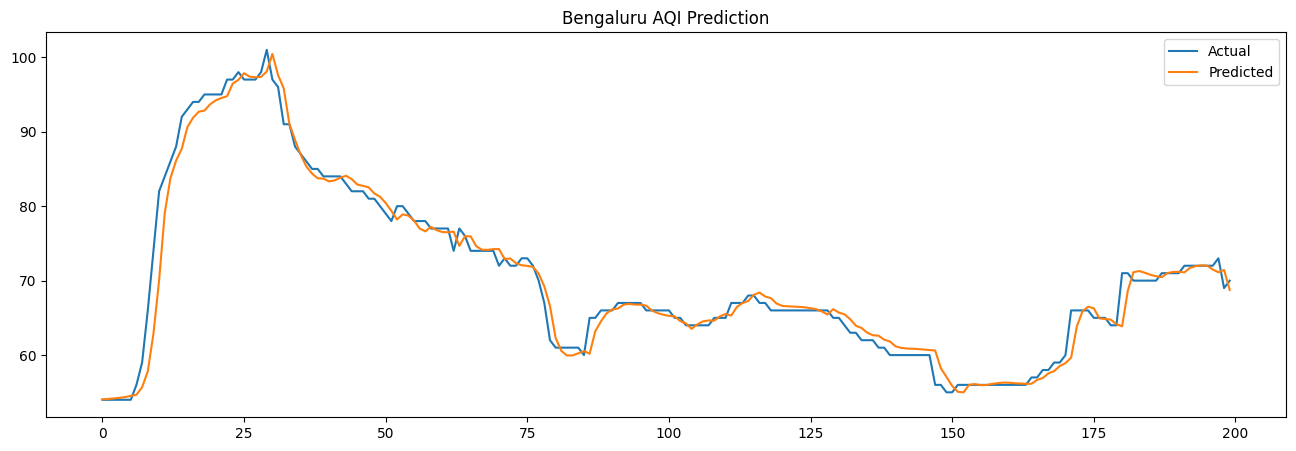

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# predict
pred = model.predict(X_test)

# inverse scale
zeros = np.zeros((len(pred),15))

zeros[:,0] = pred.flatten()
pred_actual = scaler.inverse_transform(zeros)[:,0]

zeros[:,0] = y_test
true_actual = scaler.inverse_transform(zeros)[:,0]

# metrics
mae = mean_absolute_error(true_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
r2 = r2_score(true_actual, pred_actual)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))

# graph
plt.figure(figsize=(16,5))
plt.plot(true_actual[:200], label="Actual")
plt.plot(pred_actual[:200], label="Predicted")
plt.title("Bengaluru AQI Prediction")
plt.legend()
plt.show()

In [ ]:
model.save("bengaluru_model.keras")
model.save_weights("bengaluru_weights.weights.h5")

import joblib, numpy as np
joblib.dump(scaler, "bengaluru_scaler.pkl")
np.save("bengaluru_last_sequence.npy", X[-1])

print("Bengaluru model files saved successfully")

Bengaluru model files saved successfully


In [ ]:
!zip -r models.zip *.h5 *.pkl *.npy
from google.colab import files
files.download("models.zip")

  adding: bengaluru_weights.weights.h5 (deflated 12%)
  adding: bengaluru_scaler.pkl (deflated 50%)
  adding: mumbai_scaler.pkl (deflated 50%)
  adding: bengaluru_last_sequence.npy (deflated 61%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>